# 两层 ReLU 网络函数拟合

## 1. 函数定义

本实验选取一维连续函数：

$$f(x) = \sin(3x) + 0.3x^3 - 0.5x$$

定义域取 $x \in [-2, 2]$。该函数同时包含非线性振荡项和多项式项，适合用来展示 ReLU 网络的拟合能力。

## 2. 数据采集

在区间 $[-2, 2]$ 内均匀采样训练集和测试集：

- 训练集：1024 个点
- 测试集：256 个点

输入为 $x$，输出为函数值 $f(x)$。

## 3. 模型描述

这里使用一个两层前馈网络（两层权重），结构为：

`输入(1维) -> 全连接层(128) + ReLU -> 全连接层(1维输出)`

损失函数使用均方误差（MSE），优化器使用 Adam。

## 4. 理论说明

ReLU 激活函数会把输入空间切分成若干线性区域，因此单隐藏层 ReLU 网络本质上可以表示足够复杂的分段线性函数。对定义在有界闭集上的连续函数，只要隐藏层神经元足够多，分段线性函数就可以任意逼近原函数，因此两层 ReLU 网络具有通用逼近能力。

## 5. 拟合效果

下面代码会训练模型，并给出测试集 MSE 以及“真实函数曲线 vs 网络预测曲线”的对比图。

In [6]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

np.random.seed(42)
tf.random.set_seed(42)

def target_function(x):
    return np.sin(3 * x) + 0.3 * (x ** 3) - 0.5 * x


In [7]:
x_train = np.linspace(-2.0, 2.0, 1024, dtype=np.float32).reshape(-1, 1)
x_test = np.linspace(-2.0, 2.0, 256, dtype=np.float32).reshape(-1, 1)

y_train = target_function(x_train).astype(np.float32)
y_test = target_function(x_test).astype(np.float32)

print('train_x shape:', x_train.shape)
print('train_y shape:', y_train.shape)
print('test_x shape:', x_test.shape)
print('test_y shape:', y_test.shape)


train_x shape: (1024, 1)
train_y shape: (1024, 1)
test_x shape: (256, 1)
test_y shape: (256, 1)


In [8]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(1,)),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dense(1)
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='mse',
    metrics=['mse']
)

model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 256)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 769 (3.00 KB)

 Trainable params: 769 (3.00 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
history = model.fit(
    x_train,
    y_train,
    epochs=2000,
    batch_size=64,
    verbose=0,
    validation_data=(x_test, y_test)
)

test_loss, test_mse = model.evaluate(x_test, y_test, verbose=0)
print('test loss:', float(test_loss))
print('test mse:', float(test_mse))


test loss: 0.0002526806201785803
test mse: 0.0002526806201785803


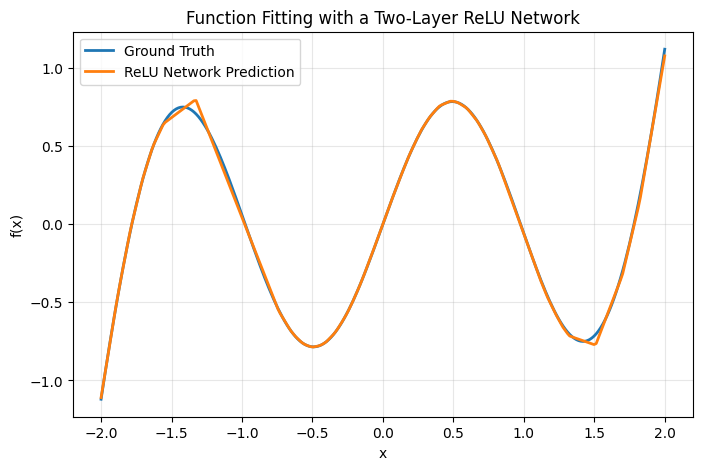

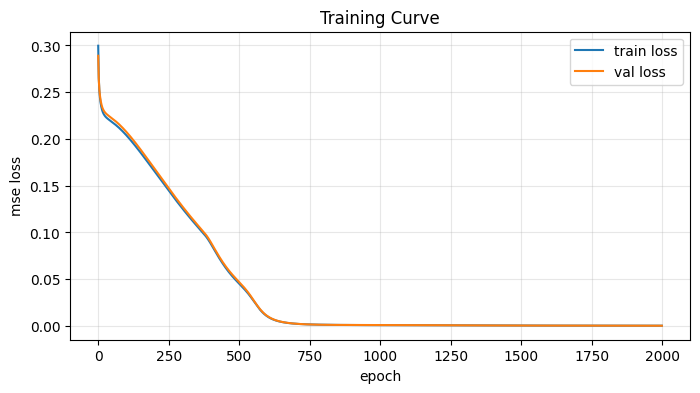

In [10]:
y_pred = model.predict(x_test, verbose=0)

plt.figure(figsize=(8, 5))
plt.plot(x_test, y_test, label='Ground Truth', linewidth=2)
plt.plot(x_test, y_pred, label='ReLU Network Prediction', linewidth=2)
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Function Fitting with a Two-Layer ReLU Network')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.xlabel('epoch')
plt.ylabel('mse loss')
plt.title('Training Curve')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## 6. 实验结论

从测试集 MSE 和曲线对比图可以看到，两层 ReLU 网络能够较好逼近所定义的连续函数。实验结果和理论一致：只要隐藏层宽度足够，ReLU 网络就可以用分段线性的方式逼近目标函数。